In [1]:
%pylab inline
import os
import sys
import pickle
import feather
import numpy as np
import seaborn as sns
import pandas as pd
import scanpy as sc
import warnings
warnings.filterwarnings('ignore')

rcParams['pdf.fonttype']=42 # in order to save fonttype in AI

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
# load the 10X data and import the class information.
ad_neurons = sc.read('../10X/data_h5/Neurons.h5ad')
ad_neurons

AnnData object with n_obs × n_vars = 38097 × 21684
    obs: 'batch', 'leiden', 'cluster_labels', 'doublet_score', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'batch_colors', 'cluster_labels_colors', 'hvg', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_harmonypca', 'X_pca', 'X_umap', 'X_umapharmony', 'X_umapraw'
    varm: 'PCs'
    layers: 'RawCounts'
    obsp: 'connectivities', 'distances'

In [3]:
clusterLabels_order = ['Exc RORB DEPTOR', 'Exc FEZF2 RSPO3', 'Exc RORB CHI3L1',
       'Exc RORB CYP26B1', 'Exc RORB FAP', 'Exc RORB CDK2AP1',
       'Exc RORB SCN7A', 'Exc RORB TRDN ', 'Exc FEZF2 SMYD1',
       'Exc HPCAL1 PENK', 'Exc HPCAL1 MEPE', 'Exc HPCAL1 FREM3',
       'Exc FEZF2 HTR2C', 'Exc HPCAL1 FRZB', 'Exc HPCAL1 KANK4',
       'Exc FEZF2 DSG2', 'Exc FEZF2 COL24A1', 'Exc RORB NRG1',
       'Exc FEZF2 LTBP3', 'Exc FEZF2 MCUB', 'Inh VIP SLIT1',
       'Inh PVALB COL5A2', 'Inh PVALB NKX2-1', 'Inh PVALB PVALB',
       'Inh SST SP5', 'Inh SST CHODL', 'Inh SST MME', 'Inh SST PENK', 'Inh SST PTK2B',
       'Inh SST ANXA2', 'Inh SST SLC30A3', 'Inh LAMP5 BCAM',
       'Inh LAMP5 SERPINF1', 'Inh LAMP5 BMP2', 'Inh SNCG CDH24',
       'Inh SNCG C1QL2', 'Inh LAMP5 GSTM2', 'Inh SNCG KLHL13',
       'Inh LAMP5 RGCC', 'Inh LAMP5 IL13RA1', 'Inh VIP RASL10A',
       'Inh SNCG ARHGAP18', 'Inh VIP SCNG', 'Inh VIP SMOC1',
       'Inh VIP CRISPLD1', 'Inh SNCG PDLIM5', 'Inh SNCG S100A6',
       'Inh SNCG PIK3CG', 'Inh SNCG ADRA1D', 'Inh VIP SHISA8',
       'Inh SERPINF1 DCN', 'Inh SNCG IGFBP2', 'Inh SNCG TPM2',]


leiden_order = ['9', '3', '11',
       '7', '13', '2',
       '0', '19 ', '4',
       '15', '1', '5',
       '10', '12', '17',
       '16', '8', '14',
       '6', '18', '52',
       '34', '50', '30',
       '40', '51', '22', '21', '28',
       '24', '44', '31',
       '49', '36', '43',
       '48', '35', '45',
       '23', '29', '27',
       '37', '20', '26',
       '32', '39', '41',
       '38', '42', '25',
       '46', '33', '47',]

In [4]:
# cluster sequence as the leiden numbers...
clusterLabels_order2 = ['Exc RORB SCN7A',
       'Exc HPCAL1 MEPE', 'Exc RORB CDK2AP1', 'Exc FEZF2 RSPO3',
       'Exc FEZF2 SMYD1', 'Exc HPCAL1 FREM3', 'Exc FEZF2 LTBP3',
       'Exc RORB CYP26B1', 'Exc FEZF2 COL24A1', 'Exc RORB DEPTOR',
       'Exc FEZF2 HTR2C', 'Exc RORB CHI3L1', 'Exc HPCAL1 FRZB', 'Exc RORB FAP',
       'Exc RORB NRG1', 'Exc HPCAL1 PENK', 'Exc FEZF2 DSG2',
       'Exc HPCAL1 KANK4', 'Exc FEZF2 MCUB', 'Exc RORB TRDN ',
                        
                        'Inh VIP SCNG', 'Inh SST PENK', 'Inh SST MME', 'Inh LAMP5 RGCC',
       'Inh SST ANXA2', 'Inh VIP SHISA8', 'Inh VIP SMOC1', 'Inh VIP RASL10A',
       'Inh SST PTK2B', 'Inh LAMP5 IL13RA1', 'Inh PVALB PVALB',
       'Inh LAMP5 BCAM', 'Inh VIP CRISPLD1', 'Inh SNCG IGFBP2',
       'Inh PVALB COL5A2', 'Inh LAMP5 GSTM2', 'Inh LAMP5 BMP2',
       'Inh SNCG ARHGAP18', 'Inh SNCG PIK3CG', 'Inh SNCG PDLIM5',
       'Inh SST SP5', 'Inh SNCG S100A6', 'Inh SNCG ADRA1D', 'Inh SNCG CDH24',
       'Inh SST SLC30A3', 'Inh SNCG KLHL13', 'Inh SERPINF1 DCN',
       'Inh SNCG TPM2', 'Inh SNCG C1QL2', 'Inh LAMP5 SERPINF1',
       'Inh PVALB NKX2-1', 'Inh SST CHODL', 'Inh VIP SLIT1', ]

In [5]:
# elecFeatTable = './data_ephy/data_ephyio_ins.csv'
elecFeatTable = '../ephysio/data_ephy/Ins_patchseq_ephs.xlsx'
rawElecFeatures = pd.read_excel(elecFeatTable,'Sheet1',index_col='Cell_ID')

In [6]:
rawElecFeatures = rawElecFeatures[~isnan(rawElecFeatures['predictCluster'])]
rawElecFeatures

,ExpertCellType,predictCluster,Tau_ms,Sag_Ratio,Rm_MO,RMP_mV,Rheobase_pA,Spike_Latency_ms,Threshold_mV,AP_Amplitute,...,ISI_phaseT_ratio_CV,latency_slope,FR_slope,firstISI_slope,ISI_adpIdx_slope,ampAdpIdx_slope,firstSpikePhaseArea,firstSpikePhasePerimeter,spikePhaseAreaRatio,spikePhasePerimeterRatio
Cell_ID,,,,,,,,,,,,,,,,,,,,,
s170,NaN,18,43.492,1.067,115.514,-65.323,140,160.66,-39.984,83.352,...,0.452,0.167,0.012,-0.21,2.263,0.1125,8906.444,568.273,3.535,1.794
s173,VEN_Long,16,33.006,1.180,88.803,-65.951,40,211.50,-55.373,98.921,...,0.514,0.397,0.054,-0.474,-6.09,-0.7318,13018.269,684.670,4.735,2.021
s174,VEN_Long,16,81.344,1.338,213.686,-59.412,60,108.58,-40.287,83.135,...,0.646,0.431,0.017,-0.164,3.938,-0.7154,8373.448,543.616,4.057,1.855
s175,PC_L5,18,55.866,1.080,159.960,-64.555,100,230.20,-38.491,79.421,...,0.144,0.187,0.031,-0.599,2.695,-0.3943,5758.154,466.527,4.386,1.929
s177,NaN,14,26.871,1.064,148.930,-55.866,180,144.06,-16.784,90.807,...,0.514,0.133,0.051,-0.346,12.025,-13.3033,10269.045,611.233,5.556,2.227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
n191,PC_L5,14,23.672,1.070,161.129,-57.289,80,74.92,-35.989,83.542,...,0.28,0.579,0.081,-0.946,1.574,-0.1229,11880.731,660.252,3.821,1.901
n193,L23_PC,15,23.377,1.115,256.807,-69.698,20,249.40,-50.287,90.344,...,0.334,0.595,0.167,-1.111,3.623,-0.9982,13609.246,701.057,7.839,2.831
n197,L23_PC,15,26.777,1.097,203.829,-66.974,80,110.20,-37.927,92.014,...,0.311,0.415,0.083,-1.061,1.119,-1.323,14299.362,724.031,9.8,3.123


In [7]:
rawElecFeatures.loc[:,'predictCluster'] = rawElecFeatures['predictCluster'].astype(int)

In [8]:
rawElecFeatures

,ExpertCellType,predictCluster,Tau_ms,Sag_Ratio,Rm_MO,RMP_mV,Rheobase_pA,Spike_Latency_ms,Threshold_mV,AP_Amplitute,...,ISI_phaseT_ratio_CV,latency_slope,FR_slope,firstISI_slope,ISI_adpIdx_slope,ampAdpIdx_slope,firstSpikePhaseArea,firstSpikePhasePerimeter,spikePhaseAreaRatio,spikePhasePerimeterRatio
Cell_ID,,,,,,,,,,,,,,,,,,,,,
s170,NaN,18,43.492,1.067,115.514,-65.323,140,160.66,-39.984,83.352,...,0.452,0.167,0.012,-0.21,2.263,0.1125,8906.444,568.273,3.535,1.794
s173,VEN_Long,16,33.006,1.180,88.803,-65.951,40,211.50,-55.373,98.921,...,0.514,0.397,0.054,-0.474,-6.09,-0.7318,13018.269,684.670,4.735,2.021
s174,VEN_Long,16,81.344,1.338,213.686,-59.412,60,108.58,-40.287,83.135,...,0.646,0.431,0.017,-0.164,3.938,-0.7154,8373.448,543.616,4.057,1.855
s175,PC_L5,18,55.866,1.080,159.960,-64.555,100,230.20,-38.491,79.421,...,0.144,0.187,0.031,-0.599,2.695,-0.3943,5758.154,466.527,4.386,1.929
s177,NaN,14,26.871,1.064,148.930,-55.866,180,144.06,-16.784,90.807,...,0.514,0.133,0.051,-0.346,12.025,-13.3033,10269.045,611.233,5.556,2.227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
n191,PC_L5,14,23.672,1.070,161.129,-57.289,80,74.92,-35.989,83.542,...,0.28,0.579,0.081,-0.946,1.574,-0.1229,11880.731,660.252,3.821,1.901
n193,L23_PC,15,23.377,1.115,256.807,-69.698,20,249.40,-50.287,90.344,...,0.334,0.595,0.167,-1.111,3.623,-0.9982,13609.246,701.057,7.839,2.831
n197,L23_PC,15,26.777,1.097,203.829,-66.974,80,110.20,-37.927,92.014,...,0.311,0.415,0.083,-1.061,1.119,-1.323,14299.362,724.031,9.8,3.123


In [9]:
predictCluster = rawElecFeatures.loc[:,'predictCluster']
dt = rawElecFeatures.drop(['predictCluster'],axis=1)

In [10]:
dt

,ExpertCellType,Tau_ms,Sag_Ratio,Rm_MO,RMP_mV,Rheobase_pA,Spike_Latency_ms,Threshold_mV,AP_Amplitute,AHP_mV,...,ISI_phaseT_ratio_CV,latency_slope,FR_slope,firstISI_slope,ISI_adpIdx_slope,ampAdpIdx_slope,firstSpikePhaseArea,firstSpikePhasePerimeter,spikePhaseAreaRatio,spikePhasePerimeterRatio
Cell_ID,,,,,,,,,,,,,,,,,,,,,
s170,NaN,43.492,1.067,115.514,-65.323,140,160.66,-39.984,83.352,-7.986,...,0.452,0.167,0.012,-0.21,2.263,0.1125,8906.444,568.273,3.535,1.794
s173,VEN_Long,33.006,1.180,88.803,-65.951,40,211.50,-55.373,98.921,NaN,...,0.514,0.397,0.054,-0.474,-6.09,-0.7318,13018.269,684.670,4.735,2.021
s174,VEN_Long,81.344,1.338,213.686,-59.412,60,108.58,-40.287,83.135,NaN,...,0.646,0.431,0.017,-0.164,3.938,-0.7154,8373.448,543.616,4.057,1.855
s175,PC_L5,55.866,1.080,159.960,-64.555,100,230.20,-38.491,79.421,-14.265,...,0.144,0.187,0.031,-0.599,2.695,-0.3943,5758.154,466.527,4.386,1.929
s177,NaN,26.871,1.064,148.930,-55.866,180,144.06,-16.784,90.807,-4.747,...,0.514,0.133,0.051,-0.346,12.025,-13.3033,10269.045,611.233,5.556,2.227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
n191,PC_L5,23.672,1.070,161.129,-57.289,80,74.92,-35.989,83.542,-16.115,...,0.28,0.579,0.081,-0.946,1.574,-0.1229,11880.731,660.252,3.821,1.901
n193,L23_PC,23.377,1.115,256.807,-69.698,20,249.40,-50.287,90.344,-13.957,...,0.334,0.595,0.167,-1.111,3.623,-0.9982,13609.246,701.057,7.839,2.831
n197,L23_PC,26.777,1.097,203.829,-66.974,80,110.20,-37.927,92.014,-12.323,...,0.311,0.415,0.083,-1.061,1.119,-1.323,14299.362,724.031,9.8,3.123


In [11]:
# # load the morphlogical features of all cells.
morphFeatMatrix = pd.read_excel('../morpho/dataMorph/morphFeatMatrix.xlsx',index_col=0)
morphFeatMatrix

,cellTypeID,cellType_expert,predictClusterID,allBasalDenLen,apicalLen,axonDist,axonLen,centroid_allBasalDenY,centroid_apicalY,centroid_axonY,...,totalApicalSurfaceArea,totalApicalVolume,totalAxonLength,totalAxonVolume,totalBasalLength,totalBasalSurfaceArea,totalBasalVolume,totalLen,totalSurfaceArea,totalVolume
B112,2,PC_L5',8,1573.569723,2471.737105,2.492281,679.656167,-40.073408,182.565365,-81.289321,...,6052.016898,1452.852726,679.656132,112.952230,1573.569670,3379.445353,627.588079,4724.962995,982.193300,2229.522436
B15,2,PC_L6',8,768.102720,2121.989931,0.919874,179.515596,-18.156018,215.944276,-75.341351,...,5374.481830,1153.040061,179.515594,92.504333,768.102694,1970.483373,435.120017,3069.608247,456.811553,1711.248169
B154,2,PC_L5',8,3573.866010,2851.954476,0.000000,189.843234,-65.531695,129.438833,-72.495039,...,17160.585810,8388.612917,189.837616,279.842268,3573.845681,20466.481440,9415.182072,6615.663719,817.057703,18318.863780
B333,3,PC_L5',16,1175.873685,4985.431714,0.000000,384.231236,-52.228937,694.344366,-116.328630,...,12409.301220,3354.256245,384.231206,74.011240,1175.873682,2576.612835,476.754165,6545.536635,594.383001,3950.097941
B361,3,PC_L5',16,2125.014867,5476.910860,0.000000,656.113741,-44.892461,902.188002,-219.729792,...,15095.723730,4397.648419,656.113703,170.800233,2125.014842,5107.076002,1053.779169,8258.039468,1184.810304,5667.386150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s722,1,PC_L5',18,1390.448694,1203.991459,0.000000,121.033303,-80.376683,127.456794,-57.690645,...,3873.260493,1082.225143,121.033295,45.257749,1390.448693,3692.432813,884.374916,2715.473456,262.363755,2050.223439
s725,1,PC_L5',18,2161.712022,2429.440311,0.000000,66.087886,-67.492119,367.272940,-32.398086,...,7054.724031,2316.335561,66.087875,48.232372,2161.712045,4739.931023,874.023682,4657.240219,189.744714,3257.442440
s727,1,PC_L5',6,3309.298558,4598.691892,0.000000,112.109683,-74.294985,308.267710,-50.322418,...,13177.754160,4578.785066,112.109673,88.453375,3309.298612,6698.096619,1170.862221,8020.100133,347.307096,7778.147988
s732,1,',6,4575.900822,2557.163073,NaN,NaN,8.578133,199.092911,NaN,...,5981.974922,1461.848069,0.000000,0.000000,4575.900916,8849.595514,1460.721038,NaN,0.000000,2951.127988


In [12]:
cellInfoTable = rawElecFeatures[{'ExpertCellType','predictCluster'}]
morphTraced=pd.DataFrame( np.ones(morphFeatMatrix.shape[0]), index=morphFeatMatrix.index,columns=['morphTraced']).astype(int)

In [13]:
# label the cells were morphologically reconstructed.
cellInfoTable.loc[cellInfoTable.index,'morphTraced']=0
cellInfoTable.loc[morphFeatMatrix.index,'morphTraced']=1

In [14]:
# adding the soma depth info into the data table.
cellInfoTable.loc[morphFeatMatrix.index,'somaDepth_norm']=morphFeatMatrix['somaDepth_norm']
cellInfoTable

,ExpertCellType,predictCluster,morphTraced,somaDepth_norm
Cell_ID,,,,
s170,NaN,18,1.0,0.619048
s173,VEN_Long,16,1.0,0.810811
s174,VEN_Long,16,1.0,0.789500
s175,PC_L5,18,1.0,0.574018
s177,NaN,14,1.0,0.531250
...,...,...,...,...
n191,PC_L5,14,0.0,NaN
n193,L23_PC,15,1.0,0.141643
n197,L23_PC,15,1.0,0.216418


In [15]:
# counting the number of cells in each cluster.
cell_counts = cellInfoTable['predictCluster'].value_counts()
cell_counts2 = cellInfoTable[cellInfoTable['morphTraced']==1]['predictCluster'].value_counts()

In [16]:
cell_counts = cell_counts.reindex(range(53))
cell_counts2=cell_counts2.reindex(range(53))

In [17]:
# reorder the clusters to align with the sequence in the previous figure.
cell_counts=cell_counts.reindex(list(map(int,leiden_order)))
cell_counts2=cell_counts2.reindex(list(map(int,leiden_order)))

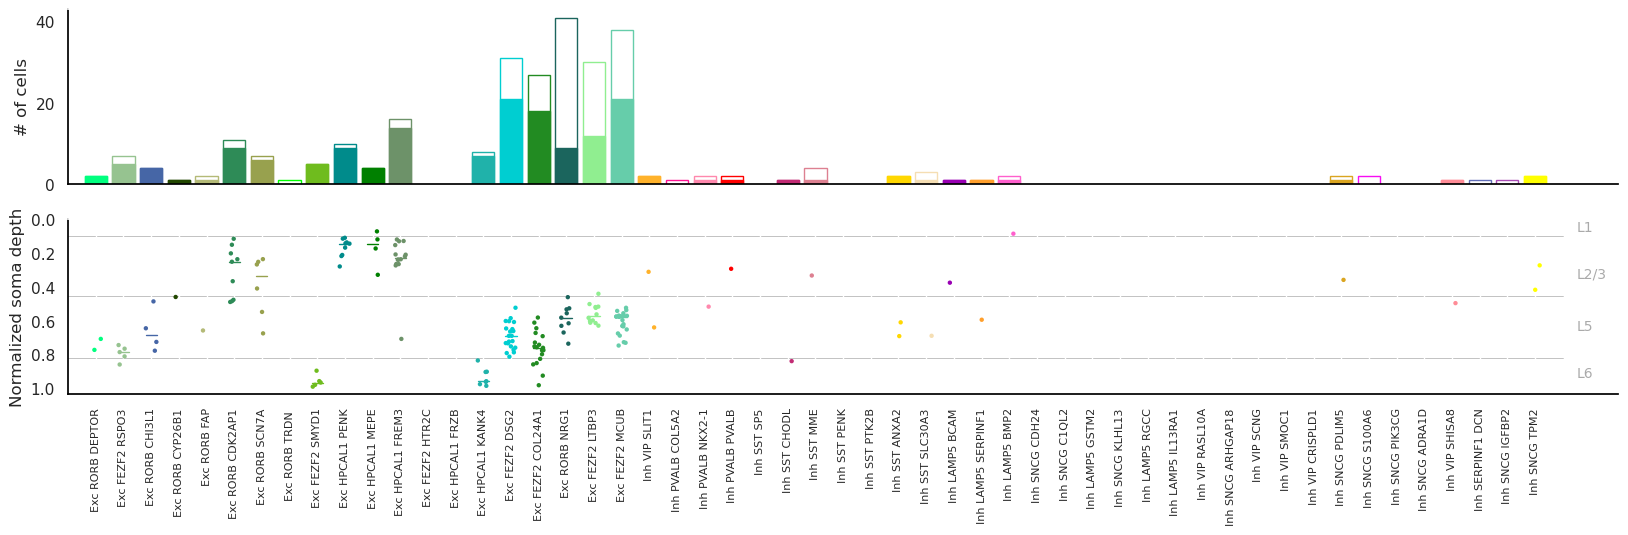

In [18]:
# plot the cell counts in each cluster.
sns.set(font_scale=1)
plt.rcParams['font.size'] = '2'

r1 = np.arange(len(cell_counts))
bars1 = cell_counts
bars2 = cell_counts2
barWidth = 0.8
bar_color = ad_neurons.uns['leiden_colors']


fig = plt.figure(figsize = (20,5))
ax = plt.subplot(2,1,1)
# Create bars
ax.bar(r1, bars1, width = barWidth, edgecolor = bar_color[cell_counts.index], color = 'none')
ax.bar(r1, bars2, width = barWidth, color = bar_color[cell_counts.index], edgecolor = bar_color[cell_counts.index])

ax.set_xticks([])
ax.set_yticks([0,20,40]) 
ax.set_xlim([-1,55])
ax.set_ylabel('# of cells')
ax.set_facecolor('white')
ax.spines['bottom'].set_color('#000000')
ax.spines['left'].set_color('#000000') 


ax = plt.subplot(2,1,2)
nCluster = len(cell_counts)
np.random.seed(42)
for i in range(nCluster):
    t = cell_counts.index[i]
    idx = cellInfoTable['predictCluster']==t
    somaDepth = cellInfoTable['somaDepth_norm'][idx]
    if somaDepth.size > 0:
        plt.scatter(i + np.random.uniform(-1,+1,size=somaDepth.size)/5, somaDepth, color=bar_color[cell_counts.index[i]], s=10, edgecolor='none')
    if somaDepth[~np.isnan(somaDepth)].size >= 3:
        plt.plot(i + np.array([-.2,.2]), np.array([1,1]) * np.median( somaDepth[~np.isnan(somaDepth)] ),
                 color=bar_color[cell_counts.index[i]], linewidth=1)

for b in np.array([0.1, 0.45,0.82]):
    plt.plot([-1, nCluster], [b,b], linewidth=.5, color='#aaaaaa', zorder=0)
for L,b in zip(['L1','L2/3','L5','L6'], [0.1/2, 0.1+(0.45-0.01)/2, 0.45+(0.82-0.45)/2, 0.82+(1-0.82)/2]):
    plt.text(nCluster+.5,b,L, color='#aaaaaa', fontsize=10, va='center')
    
ax.set_yticks([0,0.2,0.4,0.6,0.8,1]) 
ax.set_xticklabels(clusterLabels_order,rotation=90,size=8)
ax.set_xticks(np.arange(len(clusterLabels_order)))
ax.set_xlim([-1,55])
ax.set_ylabel('Normalized soma depth')
ax.set_facecolor('white')
ax.spines['bottom'].set_color('#000000')
ax.spines['left'].set_color('#000000')     
plt.gca().invert_yaxis()

# savefig('./cellDepth_patchseq.pdf',dpi=600)
# savefig('./cellDepth_patchseq.png',dpi=600)

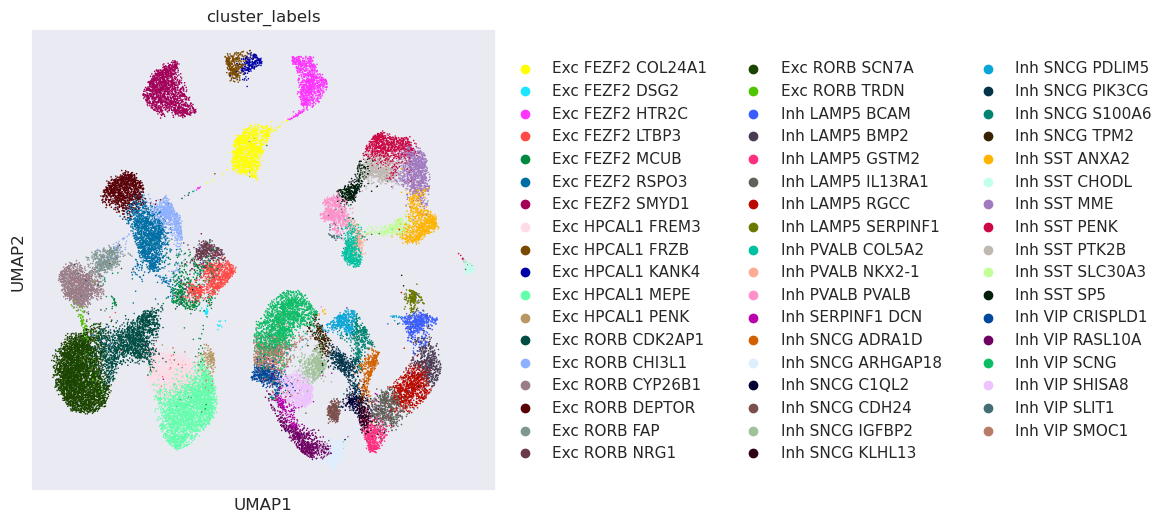

In [19]:
figsize(6,6)
sc.pl.umap(ad_neurons,color=['cluster_labels'],s=5,legend_loc='right margin')